In [1]:
"""
[example_load.py]
팀원용 데이터 로드 예시
------------------------------------------------
이 코드를 그대로 복사해서 본인 노트북 맨 위 셀에 붙여넣으면
X_train, y_train, X_val, y_val이 바로 준비됩니다.

사전 준비 (최초 1회, 프로젝트 루트에서 실행):
    python src/data.py
    python src/prepare_data.py

주의: Test 데이터(X_test, y_test)는 data/preprocessed/에 파일로 존재하지만,
최종 모델 평가 전용이라 이 example에서는 의도적으로 불러오지 않습니다.
Val로 모델을 충분히 비교한 뒤, 최종 후보가 정해지면 Test로 평가할거에요
"""

import pandas as pd
import pickle

DATA_DIR = "../../data/preprocessed"  # 노트북이 notebooks/ 안에 있다면 "../data/preprocessed"로 수정

# Train / Val만 로드 (Test 제외)
X_train = pd.read_csv(f"{DATA_DIR}/X_train.csv")
y_train = pd.read_csv(f"{DATA_DIR}/y_train.csv")["churn"]

X_val = pd.read_csv(f"{DATA_DIR}/X_val.csv")
y_val = pd.read_csv(f"{DATA_DIR}/y_val.csv")["churn"]

# 전처리 Pipeline (필요 시 새 데이터에 동일 변환 적용할 때 사용)
with open(f"{DATA_DIR}/preprocessor.pkl", "rb") as f:
    preprocessor = pickle.load(f)

print("X_train:", X_train.shape, "| X_val:", X_val.shape)
print("이탈률 - train:", y_train.mean().round(3), "| val:", y_val.mean().round(3))

# 이제 X_train, y_train으로 모델 학습하고 X_val, y_val로 성능을 비교하면 됩니다.
# 예)
#   model.fit(X_train, y_train)
#   from sklearn.metrics import recall_score
#   pred = model.predict(X_val)
#   print(recall_score(y_val, pred))

X_train: (2592, 10) | X_val: (864, 10)
이탈률 - train: 0.494 | val: 0.494


## BASELINE 설정용 로지스틱 회귀분석

In [2]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, precision_score, roc_auc_score, classification_report

X_train = pd.read_csv("../../data/preprocessed/X_train.csv")
y_train = pd.read_csv("../../data/preprocessed/y_train.csv")["churn"]
X_val = pd.read_csv("../../data/preprocessed/X_val.csv")
y_val = pd.read_csv("../../data/preprocessed/y_val.csv")["churn"]

# 다중공선성 처리: avg_days_between_orders 제외 (recency_days와 상관 0.72)
drop_cols = ["avg_days_between_orders"]
X_train_lr = X_train.drop(columns=drop_cols)
X_val_lr = X_val.drop(columns=drop_cols)

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_lr, y_train)

pred = model.predict(X_val_lr)
proba = model.predict_proba(X_val_lr)[:, 1]

print("Recall:", round(recall_score(y_val, pred), 3))
print("Precision:", round(precision_score(y_val, pred), 3))
print("AUC:", round(roc_auc_score(y_val, proba), 3))
print(classification_report(y_val, pred))

Recall: 0.677
Precision: 0.69
AUC: 0.757
              precision    recall  f1-score   support

           0       0.69      0.70      0.70       437
           1       0.69      0.68      0.68       427

    accuracy                           0.69       864
   macro avg       0.69      0.69      0.69       864
weighted avg       0.69      0.69      0.69       864



In [3]:
coef_df = pd.DataFrame({
    "feature": X_train_lr.columns,
    "coefficient": model.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False)

print(coef_df)

                 feature  coefficient
0            net_revenue    -0.557430
8  recent_activity_ratio    -0.482266
2              frequency    -0.458773
1           recency_days     0.360938
3      distinct_products    -0.316117
6                  is_uk    -0.155653
4            tenure_days     0.146562
7             has_return    -0.074126
5           is_low_value    -0.037721


In [4]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {"C": [0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid,
    scoring="recall",
    cv=5
)
grid.fit(X_train_lr, y_train)

print("최적 C:", grid.best_params_)
print("최적 Recall(CV):", round(grid.best_score_, 3))

# 최적 모델로 Val 재평가
best_model = grid.best_estimator_
pred = best_model.predict(X_val_lr)
proba = best_model.predict_proba(X_val_lr)[:, 1]

from sklearn.metrics import recall_score, precision_score, roc_auc_score

print("Val Recall:", round(recall_score(y_val, pred), 3))
print("Val Precision:", round(precision_score(y_val, pred), 3))
print("Val AUC:", round(roc_auc_score(y_val, proba), 3))

최적 C: {'C': 1}
최적 Recall(CV): 0.709
Val Recall: 0.677
Val Precision: 0.69
Val AUC: 0.757


## 랜덤포레스트

In [5]:
# 랜덤포레스트용 — 원본 10개 피처 그대로 사용 (트리 계열, 다중공선성 무관)
X_train = pd.read_csv("../../data/preprocessed/X_train.csv")
y_train = pd.read_csv("../../data/preprocessed/y_train.csv")["churn"]
X_val = pd.read_csv("../../data/preprocessed/X_val.csv")
y_val = pd.read_csv("../../data/preprocessed/y_val.csv")["churn"]

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score, roc_auc_score, classification_report

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_val)
proba = model.predict_proba(X_val)[:, 1]

print("Recall:", round(recall_score(y_val, pred), 3))
print("Precision:", round(precision_score(y_val, pred), 3))
print("AUC:", round(roc_auc_score(y_val, proba), 3))

Recall: 0.677
Precision: 0.663
AUC: 0.737


In [6]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_leaf": [1, 5, 10],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("최적 파라미터:", grid.best_params_)
print("최적 Recall(CV):", round(grid.best_score_, 3))

best_rf = grid.best_estimator_
pred = best_rf.predict(X_val)
proba = best_rf.predict_proba(X_val)[:, 1]
print("Val Recall:", round(recall_score(y_val, pred), 3))
print("Val Precision:", round(precision_score(y_val, pred), 3))
print("Val AUC:", round(roc_auc_score(y_val, proba), 3))

최적 파라미터: {'max_depth': 5, 'min_samples_leaf': 10, 'n_estimators': 300}
최적 Recall(CV): 0.773
Val Recall: 0.738
Val Precision: 0.683
Val AUC: 0.769


In [7]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [3, 4, 5, 6, 7],
    "min_samples_leaf": [5, 10, 15, 20],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("최적 파라미터:", grid.best_params_)
print("최적 Recall(CV):", round(grid.best_score_, 3))

best_rf2 = grid.best_estimator_
pred = best_rf2.predict(X_val)
proba = best_rf2.predict_proba(X_val)[:, 1]
print("Val Recall:", round(recall_score(y_val, pred), 3))
print("Val Precision:", round(precision_score(y_val, pred), 3))
print("Val AUC:", round(roc_auc_score(y_val, proba), 3))

최적 파라미터: {'max_depth': 4, 'min_samples_leaf': 5, 'n_estimators': 400}
최적 Recall(CV): 0.773
Val Recall: 0.742
Val Precision: 0.68
Val AUC: 0.767


In [8]:
from sklearn.model_selection import cross_validate

final_rf = RandomForestClassifier(
    n_estimators=400, max_depth=4, min_samples_leaf=5, random_state=42
)

cv_results = cross_validate(
    final_rf, X_train, y_train,
    cv=5,
    scoring=["recall", "precision", "roc_auc"]
)

print("Recall:", cv_results["test_recall"].mean().round(4), "±", cv_results["test_recall"].std().round(4))
print("Precision:", cv_results["test_precision"].mean().round(4), "±", cv_results["test_precision"].std().round(4))
print("AUC:", cv_results["test_roc_auc"].mean().round(4), "±", cv_results["test_roc_auc"].std().round(4))

Recall: 0.7727 ± 0.03
Precision: 0.6726 ± 0.0147
AUC: 0.7734 ± 0.0162


In [9]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.metrics import recall_score, precision_score, roc_auc_score

X_train = pd.read_csv("../../data/preprocessed/X_train.csv")
y_train = pd.read_csv("../../data/preprocessed/y_train.csv")["churn"]
X_val = pd.read_csv("../../data/preprocessed/X_val.csv")
y_val = pd.read_csv("../../data/preprocessed/y_val.csv")["churn"]

model = XGBClassifier(random_state=42, eval_metric="logloss")
model.fit(X_train, y_train)
pred = model.predict(X_val)
proba = model.predict_proba(X_val)[:, 1]
print("기본값 Recall:", round(recall_score(y_val, pred), 3))
print("기본값 Precision:", round(precision_score(y_val, pred), 3))
print("기본값 AUC:", round(roc_auc_score(y_val, proba), 3))

기본값 Recall: 0.658
기본값 Precision: 0.653
기본값 AUC: 0.73


In [10]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "min_child_weight": [1, 5, 10],
}

grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric="logloss"),
    param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("최적 파라미터:", grid.best_params_)
print("최적 Recall(CV):", round(grid.best_score_, 3))

best_xgb = grid.best_estimator_
pred = best_xgb.predict(X_val)
proba = best_xgb.predict_proba(X_val)[:, 1]
print("Val Recall:", round(recall_score(y_val, pred), 3))
print("Val Precision:", round(precision_score(y_val, pred), 3))
print("Val AUC:", round(roc_auc_score(y_val, proba), 3))

최적 파라미터: {'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 200}
최적 Recall(CV): 0.775
Val Recall: 0.731
Val Precision: 0.684
Val AUC: 0.765


In [11]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "n_estimators": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 7),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": 42,
        "eval_metric": "logloss",
        "early_stopping_rounds": 50,
    }
    model = XGBClassifier(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    return roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=100, show_progress_bar=True)

print("최적 파라미터:", study.best_params)
print("최적 AUC:", round(study.best_value, 4))

  0%|          | 0/100 [00:00<?, ?it/s]

최적 파라미터: {'learning_rate': 0.08694766035576398, 'max_depth': 4, 'min_child_weight': 11, 'reg_alpha': 0.006604000109077785, 'reg_lambda': 1.1583720234948063, 'subsample': 0.6911753101757742, 'colsample_bytree': 0.7272290625196041}
최적 AUC: 0.775


In [12]:
best_params_auc = {
    "learning_rate": 0.08694766035576398,
    "max_depth": 4,
    "min_child_weight": 11,
    "reg_alpha": 0.006604000109077785,
    "reg_lambda": 1.1583720234948063,
    "subsample": 0.6911753101757742,
    "colsample_bytree": 0.7272290625196041,
    "n_estimators": 1000,
    "random_state": 42,
    "eval_metric": "logloss",
    "early_stopping_rounds": 50,
}

best_xgb_auc = XGBClassifier(**best_params_auc)
best_xgb_auc.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

pred = best_xgb_auc.predict(X_val)
proba = best_xgb_auc.predict_proba(X_val)[:, 1]

print("Val Recall:", round(recall_score(y_val, pred), 3))
print("Val Precision:", round(precision_score(y_val, pred), 3))
print("Val AUC:", round(roc_auc_score(y_val, proba), 3))
print("사용된 트리 개수:", best_xgb_auc.best_iteration)


Val Recall: 0.749
Val Precision: 0.7
Val AUC: 0.775
사용된 트리 개수: 35


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold

X_pool = pd.concat([X_train, X_val], ignore_index=True)
y_pool = pd.concat([y_train, y_val], ignore_index=True)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []

for fold, (tr_idx, ho_idx) in enumerate(skf.split(X_pool, y_pool), 1):
    X_fold_train, X_fold_holdout = X_pool.iloc[tr_idx], X_pool.iloc[ho_idx]
    y_fold_train, y_fold_holdout = y_pool.iloc[tr_idx], y_pool.iloc[ho_idx]

    # early stopping용으로 학습 파트를 80/20으로 다시 분리 (LightGBM에서 배운 교훈: 10%는 너무 작음)
    X_tr, X_es, y_tr, y_es = train_test_split(
        X_fold_train, y_fold_train, test_size=0.2, stratify=y_fold_train, random_state=42
    )

    model = XGBClassifier(**{**best_params_auc, "n_estimators": 1000})
    model.fit(X_tr, y_tr, eval_set=[(X_es, y_es)], verbose=False)

    pred = model.predict(X_fold_holdout)
    proba = model.predict_proba(X_fold_holdout)[:, 1]
    result = {
        "fold": fold,
        "recall": recall_score(y_fold_holdout, pred),
        "precision": precision_score(y_fold_holdout, pred),
        "auc": roc_auc_score(y_fold_holdout, proba),
        "n_trees": model.best_iteration,
    }
    fold_results.append(result)
    print(f"Fold {fold}: recall={result['recall']:.4f}  precision={result['precision']:.4f}  "
          f"auc={result['auc']:.4f}  (트리 {result['n_trees']}개)")

fold_df = pd.DataFrame(fold_results).set_index("fold")
print("\n5-fold 평균 ± 표준편차")
print(fold_df[["recall", "precision", "auc"]].agg(["mean", "std"]).round(4))

Fold 1: recall=0.7368  precision=0.6961  auc=0.7830  (트리 57개)
Fold 2: recall=0.7193  precision=0.6740  auc=0.7746  (트리 45개)
Fold 3: recall=0.7419  precision=0.6819  auc=0.7666  (트리 49개)
Fold 4: recall=0.7419  precision=0.6970  auc=0.7831  (트리 99개)
Fold 5: recall=0.7771  precision=0.6795  auc=0.7721  (트리 100개)

5-fold 평균 ± 표준편차
      recall  precision     auc
mean  0.7434     0.6857  0.7759
std   0.0210     0.0103  0.0071


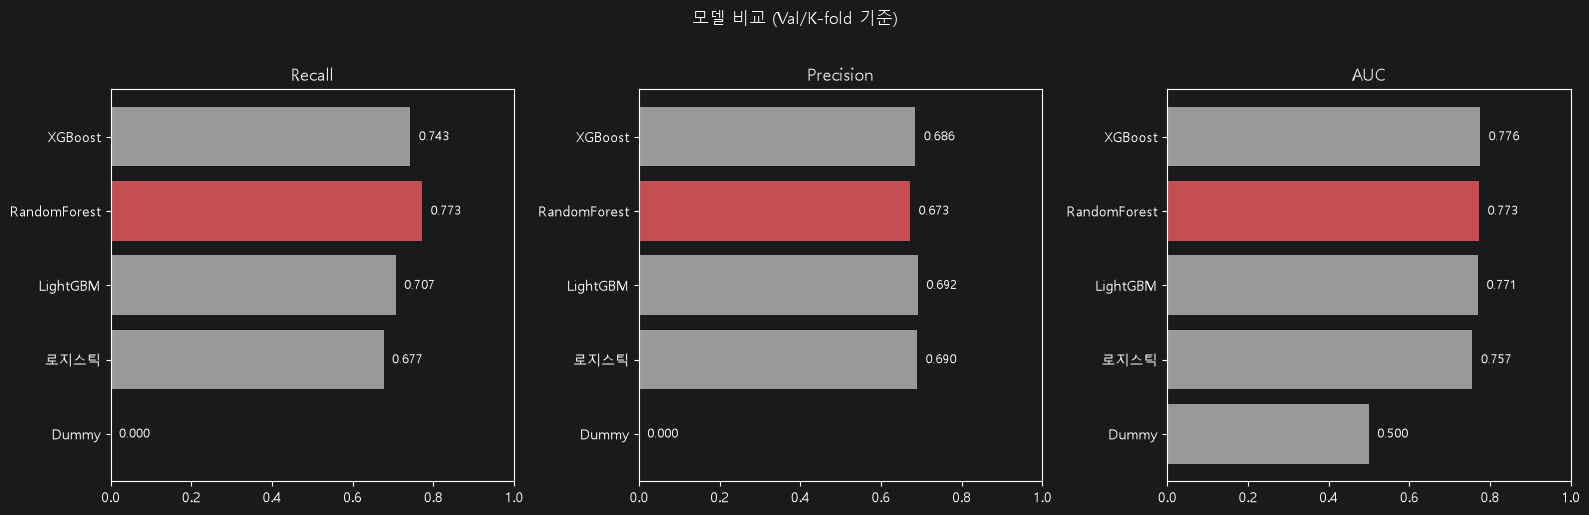

In [14]:
import matplotlib.pyplot as plt
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)
import pandas as pd

# 지금까지 확정된 K-fold 검증 결과 취합
comparison = pd.DataFrame({
    "model": ["Dummy", "로지스틱", "LightGBM", "RandomForest", "XGBoost"],
    "recall": [0.000, 0.677, 0.7071, 0.7727, 0.7434],
    "precision": [0.0, 0.690, 0.6919, 0.6726, 0.6857],
    "auc": [0.5, 0.757, 0.7708, 0.7734, 0.7759],
})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric, title in zip(axes, ["recall", "precision", "auc"], ["Recall", "Precision", "AUC"]):
    colors = ["#999999" if m != "RandomForest" else "#C44E52" for m in comparison["model"]]
    ax.barh(comparison["model"], comparison[metric], color=colors)
    ax.set_title(title)
    ax.set_xlim(0, 1)
    for i, v in enumerate(comparison[metric]):
        ax.text(v + 0.02, i, f"{v:.3f}", va="center", fontsize=9)

fig.suptitle("모델 비교 (Val/K-fold 기준)", y=1.02)
plt.tight_layout()
plt.show()